<a href="https://colab.research.google.com/github/najiyak23/Retail-Store-Trial-Analysis/blob/main/Quatium_DA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 1: Data Loading And Cleaning

## 1. Import the required libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Optional: Improve plot appearance
plt.style.use('ggplot')

## 2. Load the datasets

In [ ]:
# Load transaction data
transaction_data = pd.read_excel("QVI_transaction_data.xlsx")

# Load customer behaviour data
purchase_behaviour = pd.read_csv("QVI_purchase_behaviour.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'QVI_transaction_data.xlsx'

## 3. Display the first few rows

In [ ]:
transaction_data.head()

In [ ]:
purchase_behaviour.head()

## 4. Check the shape of each dataset

In [ ]:
transaction_data.shape

In [ ]:
purchase_behaviour.shape

##5. Examine dataset information

In [ ]:
transaction_data.info()

In [ ]:
purchase_behaviour.info()

## 6. Summary statistics

In [ ]:
transaction_data.describe()

In [ ]:
purchase_behaviour.describe()

## 7. Checking missing values

In [ ]:
transaction_data.isnull().sum()

In [ ]:
purchase_behaviour.isnull().sum()

In [ ]:
transactions_per_day = (
    transaction_data.groupby("DATE")
    .size()
)

transactions_per_day.plot(figsize=(12,5))

1. No long gaps in the timeline ✅

        * Transactions are recorded continuously from July 2018 to June 2019.
        * There are no missing weeks or months.

2. Most days have similar transaction volumes ✅

        * Around 640–700 transactions per day, which is fairly consistent.

3. A noticeable spike occurs around late December 2018 ⚠️

       * Daily transactions increase to around 850–870.

       * This is expected because of the Christmas/New Year holiday period, when supermarkets typically experience higher sales.

       * Since the spike is brief and coincides with a holiday season, it is not considered a data quality issue.

In [ ]:
transactions_per_day = transaction_data.groupby("DATE").size()

# Create a complete date range
all_dates = pd.date_range(
    start=transaction_data["DATE"].min(),
    end=transaction_data["DATE"].max()
)

missing_dates = all_dates.difference(transactions_per_day.index)
print(missing_dates)

There is only one day with no transactions (25 December 2018), which is likely due to the store being closed for Christmas rather than missing data.

**CONCLUSION**

Transaction activity was consistent throughout the year with no prolonged gaps or unusual fluctuations. A temporary increase in transaction volume was observed during the Christmas/New Year period, which is consistent with expected seasonal shopping behavior. The only day with no recorded transactions was 25 December 2018, likely because stores were closed for Christmas rather than due to missing data.


## 8. Checking for duplicates

In [ ]:
transaction_data.duplicated().sum()

In [ ]:
purchase_behaviour.duplicated().sum()

In [ ]:
transaction_data[transaction_data.duplicated()]

In [ ]:
transaction_data = transaction_data.drop_duplicates()

## Investigating Outliers

In [ ]:
# Frequency of each quantity purchased
transaction_data["PROD_QTY"].value_counts().sort_index()

In [ ]:
transaction_data[transaction_data["PROD_QTY"] == 200]

In [ ]:
transaction_data[transaction_data["LYLTY_CARD_NBR"] == 226000]

In [ ]:
transaction_data = transaction_data[
    transaction_data["LYLTY_CARD_NBR"] != 226000
]

During exploratory analysis, two transactions were identified where a single customer purchased 200 packets of chips. These purchases were far outside the normal transaction range of 1–5 packets and appear to represent bulk or commercial purchases rather than typical consumer behaviour. Since the objective is to analyze regular customer purchasing patterns, these two transactions were excluded from further analysis.

In [ ]:
# Remove bulk purchase transactions
transaction_data = transaction_data[transaction_data["PROD_QTY"] != 200]

In [ ]:
transaction_data.describe()

 Cnverting Date

In [ ]:
transaction_data["DATE"] = pd.to_datetime(
    transaction_data["DATE"],
    origin="1899-12-30",
    unit="D"
)

In [ ]:
transaction_data["DATE"].head()

## Cleaning the Product Names

In [ ]:
transaction_data["PROD_NAME"].head(10)

In [ ]:
transaction_data["PROD_NAME"].nunique()

In [ ]:
transaction_data["PROD_NAME"].value_counts().head(20)

In [ ]:
transaction_data[
    transaction_data["PROD_NAME"].str.contains("salsa", case=False)
]

In [ ]:
transaction_data[
    transaction_data["PROD_NAME"].str.contains("salsa", case=False)
]["PROD_NAME"].unique()

In [ ]:
#Remove Salsa products
transaction_data = transaction_data[
    ~transaction_data["PROD_NAME"].str.contains("salsa", case=False)
]

In [ ]:
#Extracting Pack Size
transaction_data["PACK_SIZE"] = (
    transaction_data["PROD_NAME"]
    .str.extract(r'(\d+)')
    .astype(int)
)

In [ ]:
transaction_data[["PROD_NAME", "PACK_SIZE"]].head(10)

In [ ]:
transaction_data["PACK_SIZE"].describe()

In [ ]:
#Extracting Brand
transaction_data["BRAND"] = (
    transaction_data["PROD_NAME"]
    .str.split()
    .str[0]
)

In [ ]:
transaction_data[["PROD_NAME", "BRAND"]].head(20)

In [ ]:
transaction_data["BRAND"].value_counts()

In [ ]:
transaction_data["PROD_NAME"].unique()

In [ ]:
transaction_data[["PROD_NAME", "BRAND"]].head(20)

In [ ]:
def extract_brand(product):
    product = " ".join(product.split())  # remove extra spaces

    if product.startswith("Natural Chip"):
        return "Natural Chip Co"
    elif product.startswith("Grain Waves"):
        return "Grain Waves"
    elif product.startswith("Burger Rings"):
        return "Burger Rings"
    elif product.startswith("Red Rock Deli"):
        return "Red Rock Deli"
    elif product.startswith("French Fries"):
        return "French Fries"
    elif product.startswith("Old El Paso"):
        return "Old El Paso"
    else:
        return product.split()[0]

transaction_data["BRAND"] = transaction_data["PROD_NAME"].apply(extract_brand)

# Standardize abbreviations and spelling
brand_mapping = {
    "RRD": "Red Rock Deli",
    "GrnWves": "Grain Waves",
    "NCC": "Natural Chip Co",
    "Infzns": "Infuzions",
    "Snbts": "Sunbites",
    "WW": "Woolworths",
    "Smith": "Smiths",
    "Dorito": "Doritos"
}

transaction_data["BRAND"] = transaction_data["BRAND"].replace(brand_mapping)

In [ ]:
transaction_data["BRAND"].value_counts().sort_index()

## Merge the Datasets

In [ ]:
merged_data = transaction_data.merge(
    purchase_behaviour,
    on="LYLTY_CARD_NBR",
    how="left"
)

In [ ]:
merged_data.shape
merged_data.head()
merged_data.info()

In [ ]:
merged_data.isnull().sum()

# Exploratory Data Analysis (EDA)

1. Total Sales

In [ ]:
merged_data["TOT_SALES"].sum()

In [ ]:
brand_sales = (
    merged_data.groupby("BRAND")["TOT_SALES"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))
brand_sales.plot(kind="bar")
plt.title("Top 10 Brands by Sales")
plt.xlabel("Brand")
plt.ylabel("Total Sales ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Business question:

> How much revenue did the chip category generate?



2. Total Transactions

In [ ]:
merged_data["TXN_ID"].nunique()

Business question:

> How many chip purchases were made?

3. Total Customers

In [ ]:
merged_data["LYLTY_CARD_NBR"].nunique()

Business question:

> How many unique customers purchased chips?

4. Total Quantity Sold

In [ ]:
merged_data["PROD_QTY"].sum()

Business question:

> How many packets of chips were sold?

5. Average Transaction Value

In [ ]:
merged_data["TOT_SALES"].mean()

6. Average Packets per Transaction

In [ ]:
merged_data["PROD_QTY"].mean()

# Customer Segment Analysis

Total Sales by LIFESTAGE

In [ ]:
sales_by_lifestage = (
    merged_data.groupby("LIFESTAGE")["TOT_SALES"]
    .sum()
    .sort_values(ascending=False)
)

print(sales_by_lifestage)

In [ ]:
import seaborn as sns

pivot = merged_data.pivot_table(
    values="TOT_SALES",
    index="LIFESTAGE",
    columns="PREMIUM_CUSTOMER",
    aggfunc="sum"
)

plt.figure(figsize=(8,6))
sns.heatmap(pivot, annot=True, fmt=".0f")
plt.title("Total Sales by Customer Segment")
plt.show()

Question answered:

> Which life stage contributes the most revenue?

**Insight**

* Older Singles/Couples generate the highest total chip sales.

* Retirees and Older Families are also major contributors.
* New Families contribute the least revenue.

This indicates that older customer groups are very important to the chip category.

Total Sales by PREMIUM_CUSTOMER

In [ ]:
#Total Sales by PREMIUM_CUSTOMER
sales_by_premium = (
    merged_data.groupby("PREMIUM_CUSTOMER")["TOT_SALES"]
    .sum()
    .sort_values(ascending=False)
)

print(sales_by_premium)

Question answered:

> Which customer type contributes the most revenue?

**Insight**
* Mainstream customers generate the highest overall sales.
* Premium customers contribute the lowest total revenue.

This suggests the largest revenue opportunity lies within the mainstream market.

Sales by LIFESTAGE and PREMIUM_CUSTOMER

In [ ]:
#Sales by LIFESTAGE and PREMIUM_CUSTOMER
sales_segment = (
    merged_data.groupby(
        ["LIFESTAGE", "PREMIUM_CUSTOMER"]
    )["TOT_SALES"]
    .sum()
    .sort_values(ascending=False)
)

print(sales_segment)

**Insight**

Although **Older Families – Budget** generate the highest revenue, this doesn't automatically make them the best target. We need to consider **how many customers are in each segment.**

Number of Customers in Each Segment

In [ ]:
#Number of Customers in Each Segment
customer_count = (
    merged_data.groupby(
        ["LIFESTAGE", "PREMIUM_CUSTOMER"]
    )["LYLTY_CARD_NBR"]
    .nunique()
)

print(customer_count)

**Insight**

The **Young Singles/Couples – Mainstream** segment has by far the largest customer base.

This means its high sales are supported by **many customers**, making it a valuable segment for marketing.

Average Spend per Customer

In [ ]:
avg_spend = (
    merged_data.groupby(
        ["LIFESTAGE", "PREMIUM_CUSTOMER"]
    )["TOT_SALES"]
    .mean()
)

print(avg_spend)

**Insight**

The **Young Singles/Couples** **– Mainstream** segment has the highest average spend per transaction among the major customer groups.

In [ ]:
customer_spend = (
    merged_data
    .groupby(
        ["LYLTY_CARD_NBR", "LIFESTAGE", "PREMIUM_CUSTOMER"]
    )["TOT_SALES"]
    .sum()
    .reset_index()
)

avg_spend_customer = customer_spend.pivot_table(
    values="TOT_SALES",
    index="LIFESTAGE",
    columns="PREMIUM_CUSTOMER",
    aggfunc="mean"
).loc[order]

ax = avg_spend_customer.plot(kind="bar", figsize=(10,6), width=0.8)

ax.set_title("Average Spend per Customer")
ax.set_xlabel("Lifestage")
ax.set_ylabel("Average Spend per Customer ($)")
plt.xticks(rotation=90)
plt.legend(title="PREMIUM_CUSTOMER")
plt.tight_layout()
plt.show()

Average Quantity Purchased

In [ ]:
avg_qty = (
    merged_data.groupby(
        ["LIFESTAGE", "PREMIUM_CUSTOMER"]
    )["PROD_QTY"]
    .mean()
)

print(avg_qty)

**Insight**

Families tend to purchase more packets per shopping trip, likely because they are buying for multiple people.

Average Price per Packet

In [ ]:
# Average Price per Packet
merged_data["PRICE_PER_PACKET"] = (
    merged_data["TOT_SALES"] /
    merged_data["PROD_QTY"]
)

In [ ]:
price_per_packet = (
    merged_data.groupby(
        ["LIFESTAGE", "PREMIUM_CUSTOMER"]
    )["PRICE_PER_PACKET"]
    .mean()
)

print(price_per_packet)

**Insight**

This is one of the strongest findings:

> **Young Singles/Couples – Mainstream** pay the highest average price per packet.

This suggests they are more willing to purchase premium or higher-priced chip products.

**Overall Business Interpretation**

---



If we combine all of these findings:

* Older Families – Budget generate the highest total sales.
* Young Singles/Couples – Mainstream have:

    * the largest customer base,
    * very high total sales,
    * the highest average spend per transaction,
     * and the highest average price per packet.

These characteristics make Young Singles/Couples – Mainstream a particularly attractive segment because they represent both high value and high growth potential.

In [ ]:
import matplotlib.pyplot as plt

# Create pivot table
price_chart = merged_data.pivot_table(
    values="PRICE_PER_PACKET",
    index="LIFESTAGE",
    columns="PREMIUM_CUSTOMER",
    aggfunc="mean"
)

order = [
    "MIDAGE SINGLES/COUPLES",
    "NEW FAMILIES",
    "OLDER FAMILIES",
    "OLDER SINGLES/COUPLES",
    "RETIREES",
    "YOUNG FAMILIES",
    "YOUNG SINGLES/COUPLES"
]

price_chart = price_chart.loc[order]

# Plot
ax = price_chart.plot(
    kind="bar",
    figsize=(10,6),
    width=0.8
)

ax.set_title("Price per unit")
ax.set_xlabel("Lifestage")
ax.set_ylabel("Avg price per unit")
plt.xticks(rotation=90)

plt.legend(title="PREMIUM_CUSTOMER")
plt.tight_layout()
plt.show()

# Recommendation for Julia

**Recommendation 1**: Focus marketing efforts on **Young Singles/Couples – Mainstream,** as they represent the largest customer segment and pay the highest average price per packet, indicating a willingness to purchase higher-value products.

**Recommendation 2**: Continue supporting **Older Families – Budget,** as they contribute the highest total sales and purchase the greatest number of chip packets per transaction. Promotions such as family-size packs or multi-buy offers may further strengthen this segment.

**Observation**: **New Families** currently contribute the least revenue and may be considered a lower priority for targeted marketing based on the current analysis.

> Position premium brands and new product launches toward Young Singles/Couples – Mainstream, while offering value-focused promotions and larger pack sizes to Older Families – Budget.

# Deep Analysis into Customer Segment

### Brand Preference

In [ ]:
brand_sales = (
    merged_data.groupby(["LIFESTAGE", "PREMIUM_CUSTOMER", "BRAND"])["TOT_SALES"]
    .sum()
    .reset_index()
)

In [ ]:
ys_mainstream = brand_sales[
    (brand_sales["LIFESTAGE"] == "YOUNG SINGLES/COUPLES") &
    (brand_sales["PREMIUM_CUSTOMER"] == "Mainstream")
]

ys_mainstream.sort_values("TOT_SALES", ascending=False).head(10)

In [ ]:
target_brand = (
    ys_mainstream
    .sort_values("TOT_SALES", ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))
plt.bar(target_brand["BRAND"], target_brand["TOT_SALES"])
plt.title("Top Brands for Young Singles/Couples - Mainstream")
plt.xlabel("Brand")
plt.ylabel("Total Sales ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

This answers:

> Which brands do Young Singles/Couples – Mainstream prefer?

**Business Insight**
* **Kettle** is by far the most popular brand among **Young Singles/Couples – Mainstream.**
* **Doritos, Pringles,** and **Smiths** are also strong performers.
* These customers appear to prefer well-known and premium-style brands.

**Recommendation**

> Increase promotions and shelf visibility for Kettle, Doritos, Pringles, and Smiths when targeting Young Singles/Couples – Mainstream.

### Pack Size Preference

In [ ]:
pack_sales = (
    merged_data.groupby(
        ["LIFESTAGE", "PREMIUM_CUSTOMER", "PACK_SIZE"]
    )["TOT_SALES"]
    .sum()
    .reset_index()
)

In [ ]:
ys_pack = pack_sales[
    (pack_sales["LIFESTAGE"] == "YOUNG SINGLES/COUPLES") &
    (pack_sales["PREMIUM_CUSTOMER"] == "Mainstream")
]

ys_pack.sort_values("TOT_SALES", ascending=False)

**Recommendation**

> Prioritize stocking and promoting **175g** and **150g** packs for the **Young Singles/Couples – Mainstream** segment, as these are their preferred sizes.

# **TASK 2**

In [ ]:
import pandas as pd

# Load the dataset
qvi_data = pd.read_csv("QVI_data.csv")

# View the first few rows
qvi_data.head()

,LYLTY_CARD_NBR,DATE,STORE_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,2018-10-17,1,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175,NATURAL,YOUNG SINGLES/COUPLES,Premium
1,1002,2018-09-16,1,2,58,Red Rock Deli Chikn&Garlic Aioli 150g,1,2.7,150,RRD,YOUNG SINGLES/COUPLES,Mainstream
2,1003,2019-03-07,1,3,52,Grain Waves Sour Cream&Chives 210G,1,3.6,210,GRNWVES,YOUNG FAMILIES,Budget
3,1003,2019-03-08,1,4,106,Natural ChipCo Hony Soy Chckn175g,1,3.0,175,NATURAL,YOUNG FAMILIES,Budget
4,1004,2018-11-02,1,5,96,WW Original Stacked Chips 160g,1,1.9,160,WOOLWORTHS,OLDER SINGLES/COUPLES,Mainstream


In [ ]:
qvi_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264834 entries, 0 to 264833
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   LYLTY_CARD_NBR    264834 non-null  int64  
 1   DATE              264834 non-null  object 
 2   STORE_NBR         264834 non-null  int64  
 3   TXN_ID            264834 non-null  int64  
 4   PROD_NBR          264834 non-null  int64  
 5   PROD_NAME         264834 non-null  object 
 6   PROD_QTY          264834 non-null  int64  
 7   TOT_SALES         264834 non-null  float64
 8   PACK_SIZE         264834 non-null  int64  
 9   BRAND             264834 non-null  object 
 10  LIFESTAGE         264834 non-null  object 
 11  PREMIUM_CUSTOMER  264834 non-null  object 
dtypes: float64(1), int64(6), object(5)
memory usage: 24.2+ MB


In [ ]:
qvi_data["DATE"] = pd.to_datetime(qvi_data["DATE"])

Creating a Year-Month column

In [ ]:
qvi_data["YEARMONTH"] = qvi_data["DATE"].dt.to_period("M")

In [ ]:
qvi_data[["DATE", "YEARMONTH"]].head()

,DATE,YEARMONTH
0,2018-10-17,2018-10
1,2018-09-16,2018-09
2,2019-03-07,2019-03
3,2019-03-08,2019-03
4,2018-11-02,2018-11


Creating the Monthly Store Metrics

In [ ]:
monthly_metrics = (
    qvi_data.groupby(["STORE_NBR", "YEARMONTH"])
    .agg(
        TOT_SALES=("TOT_SALES", "sum"),
        N_CUSTOMERS=("LYLTY_CARD_NBR", "nunique"),
        N_TRANSACTIONS=("TXN_ID", "nunique")
    )
    .reset_index()
)

Average Transactions per Customer

In [ ]:
monthly_metrics["TXN_PER_CUSTOMER"] = (
    monthly_metrics["N_TRANSACTIONS"] /
    monthly_metrics["N_CUSTOMERS"]
)
monthly_metrics.head()

,STORE_NBR,YEARMONTH,TOT_SALES,N_CUSTOMERS,N_TRANSACTIONS,TXN_PER_CUSTOMER
0,1,2018-07,206.9,49,52,1.061224
1,1,2018-08,176.1,42,43,1.023810
2,1,2018-09,278.8,59,62,1.050847
3,1,2018-10,188.1,44,45,1.022727
4,1,2018-11,192.6,46,47,1.021739


In [ ]:
print(monthly_metrics.shape)

(3169, 6)


Pre-Trial Data

In [ ]:
pre_trial = monthly_metrics[
    monthly_metrics["YEARMONTH"] < "2019-02"
].copy()

pre_trial.head()

,STORE_NBR,YEARMONTH,TOT_SALES,N_CUSTOMERS,N_TRANSACTIONS,TXN_PER_CUSTOMER
0,1,2018-07,206.9,49,52,1.061224
1,1,2018-08,176.1,42,43,1.023810
2,1,2018-09,278.8,59,62,1.050847
3,1,2018-10,188.1,44,45,1.022727
4,1,2018-11,192.6,46,47,1.021739


In [ ]:
print(pre_trial["YEARMONTH"].unique())

<PeriodArray>
['2018-07', '2018-08', '2018-09', '2018-10', '2018-11', '2018-12', '2019-01']
Length: 7, dtype: period[M]


### Correlation Function

In [ ]:
import pandas as pd

def calculate_correlation(data, trial_store, metric):
    """
    Calculate Pearson correlation between the trial store
    and every other store for a given metric.
    """

    # Convert data into wide format
    pivot = data.pivot(
        index="YEARMONTH",
        columns="STORE_NBR",
        values=metric
    )

    # Correlation of every store with the trial store
    correlation = pivot.corr()[trial_store]

    # Convert to dataframe
    correlation = correlation.reset_index()

    correlation.columns = ["STORE_NBR", "CORRELATION"]

    # Remove the trial store itself
    correlation = correlation[
        correlation["STORE_NBR"] != trial_store
    ]

    # Sort from highest to lowest
    correlation = correlation.sort_values(
        "CORRELATION",
        ascending=False
    )

    return correlation

In [ ]:
sales_corr_77 = calculate_correlation(
    pre_trial,
    trial_store=77,
    metric="TOT_SALES"
)

sales_corr_77.head(10)

,STORE_NBR,CORRELATION
30,31,1.000000
10,11,1.000000
70,71,0.914106
231,233,0.903774
117,119,0.867664
16,17,0.842668
2,3,0.806644
40,41,0.783232
49,50,0.763866
155,157,0.735893


### Magnitude Distance Function

In [ ]:
def calculate_magnitude_distance(data, trial_store, metric):
    """
    Calculate similarity based on the magnitude (actual values)
    between the trial store and all other stores.
    """

    pivot = data.pivot(
        index="YEARMONTH",
        columns="STORE_NBR",
        values=metric
    )

    # Absolute difference from trial store
    distance = pivot.subtract(pivot[trial_store], axis=0).abs()

    # Average monthly difference
    avg_distance = distance.mean()

    # Convert to similarity score (higher = more similar)
    similarity = 1 - (
        (avg_distance - avg_distance.min()) /
        (avg_distance.max() - avg_distance.min())
    )

    similarity = similarity.reset_index()
    similarity.columns = ["STORE_NBR", "MAGNITUDE"]

    # Remove the trial store itself
    similarity = similarity[
        similarity["STORE_NBR"] != trial_store
    ]

    # Sort by similarity
    similarity = similarity.sort_values(
        "MAGNITUDE",
        ascending=False
    )

    return similarity

In [ ]:
sales_mag_77 = calculate_magnitude_distance(
    pre_trial,
    trial_store=77,
    metric="TOT_SALES"
)

sales_mag_77.head(10)

,STORE_NBR,MAGNITUDE
231,233,0.984567
253,255,0.976581
186,188,0.974509
52,53,0.973385
129,131,0.972916
45,46,0.972764
212,214,0.971769
49,50,0.971546
203,205,0.970445
185,187,0.969111


**Metrices**

In [ ]:
def similarity_scores(data, trial_store, metric):
    corr = calculate_correlation(data, trial_store, metric)
    mag = calculate_magnitude_distance(data, trial_store, metric)

    scores = corr.merge(mag, on="STORE_NBR")

    scores["FINAL_SCORE"] = (
        scores["CORRELATION"] + scores["MAGNITUDE"]
    ) / 2

    return scores.sort_values(
        "FINAL_SCORE",
        ascending=False
    )

Total Sales

In [ ]:
sales_scores = similarity_scores(
    pre_trial,
    77,
    "TOT_SALES"
)

sales_scores.head(10)

,STORE_NBR,CORRELATION,MAGNITUDE,FINAL_SCORE
3,233,0.903774,0.984567,0.944171
0,31,1.000000,0.813241,0.906620
1,11,1.000000,0.809389,0.904694
7,41,0.783232,0.962834,0.873033
8,50,0.763866,0.971546,0.867706
5,17,0.842668,0.872450,0.857559
13,115,0.689159,0.928151,0.808655
15,167,0.657110,0.956160,0.806635
16,265,0.639759,0.960434,0.800097
12,234,0.696325,0.882227,0.789276


Number of Customers

In [ ]:
customer_scores = similarity_scores(
    pre_trial,
    77,
    "N_CUSTOMERS"
)

customer_scores.head(10)

,STORE_NBR,CORRELATION,MAGNITUDE,FINAL_SCORE
0,233,0.990358,0.992343,0.991350
2,254,0.916208,0.934150,0.925179
5,41,0.844219,0.973966,0.909093
4,84,0.858571,0.920368,0.889469
12,17,0.747308,0.961715,0.854511
15,115,0.718882,0.963247,0.841064
7,35,0.774647,0.903522,0.839085
16,167,0.717913,0.947933,0.832923
20,111,0.685926,0.964778,0.825352
19,27,0.686386,0.947933,0.817160


Transactions per Customer

In [ ]:
txn_scores = similarity_scores(
    pre_trial,
    77,
    "TXN_PER_CUSTOMER"
)

txn_scores.head(10)

,STORE_NBR,CORRELATION,MAGNITUDE,FINAL_SCORE
0,176,0.881098,0.896913,0.889005
10,37,0.715181,0.917171,0.816176
12,251,0.699256,0.920043,0.809650
16,22,0.629620,0.873877,0.751748
18,145,0.601015,0.886723,0.743869
21,240,0.582753,0.902188,0.742471
5,119,0.802529,0.649724,0.726127
29,248,0.480121,0.902853,0.691487
30,103,0.476365,0.890506,0.683436
33,249,0.444570,0.896225,0.670398


### Monthly Total Sales (Pre-Trial)

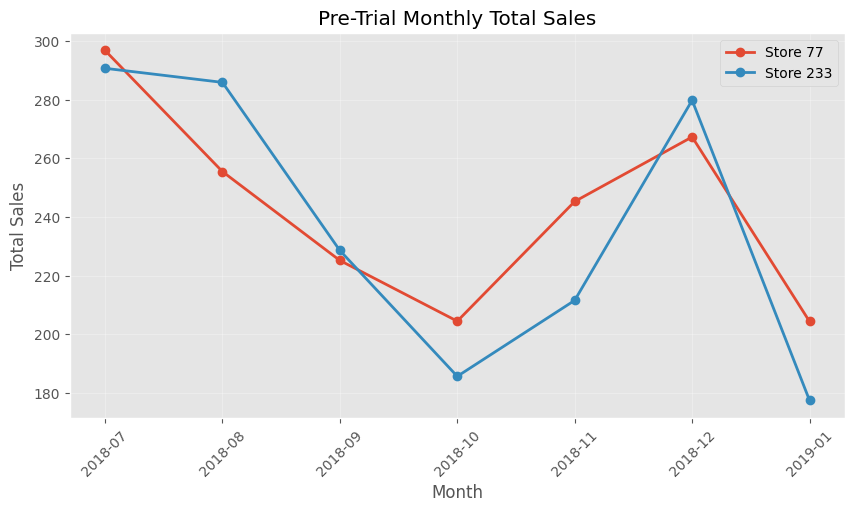

In [ ]:
import matplotlib.pyplot as plt

# Select trial and control stores
trial_store = 77
control_store = 233

# Filter pre-trial data
plot_data = pre_trial[
    pre_trial["STORE_NBR"].isin([trial_store, control_store])
]

# Create the plot
plt.figure(figsize=(10,5))

for store in [trial_store, control_store]:
    temp = plot_data[plot_data["STORE_NBR"] == store]
    plt.plot(
        temp["YEARMONTH"].astype(str),
        temp["TOT_SALES"],
        marker="o",
        linewidth=2,
        label=f"Store {store}"
    )

plt.title("Pre-Trial Monthly Total Sales")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Monthly Number of Customers

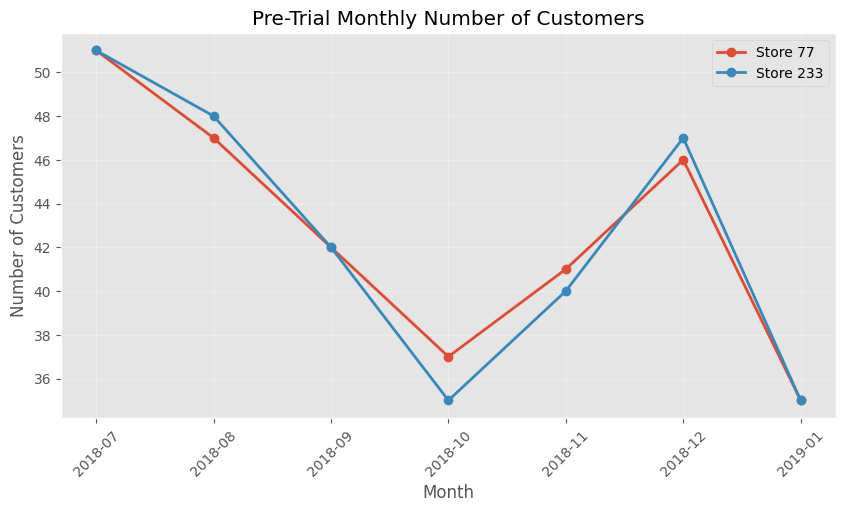

In [ ]:
plt.figure(figsize=(10,5))

for store in [trial_store, control_store]:
    temp = plot_data[plot_data["STORE_NBR"] == store]
    plt.plot(
        temp["YEARMONTH"].astype(str),
        temp["N_CUSTOMERS"],
        marker="o",
        linewidth=2,
        label=f"Store {store}"
    )

plt.title("Pre-Trial Monthly Number of Customers")
plt.xlabel("Month")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Monthly Transactions per Customer

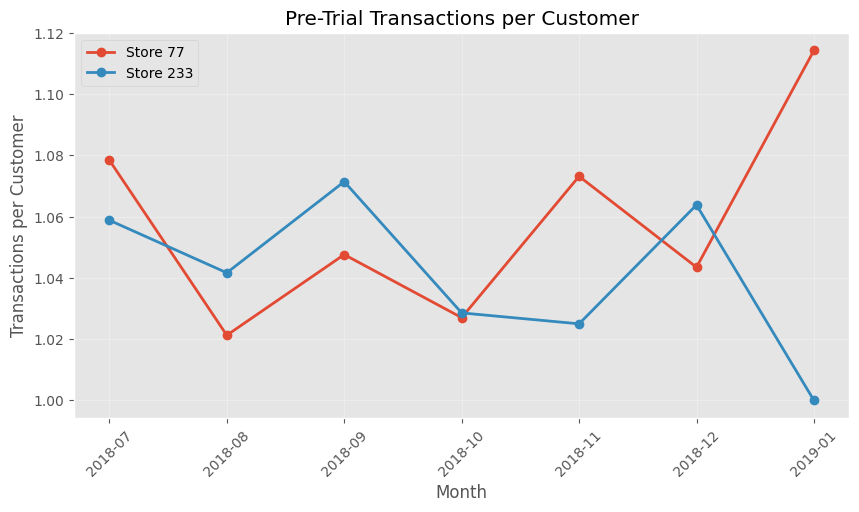

In [ ]:
plt.figure(figsize=(10,5))

for store in [trial_store, control_store]:
    temp = plot_data[plot_data["STORE_NBR"] == store]
    plt.plot(
        temp["YEARMONTH"].astype(str),
        temp["TXN_PER_CUSTOMER"],
        marker="o",
        linewidth=2,
        label=f"Store {store}"
    )

plt.title("Pre-Trial Transactions per Customer")
plt.xlabel("Month")
plt.ylabel("Transactions per Customer")
plt.xticks(rotation=45)
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Compare Trial vs Control During the Trial Period

In [ ]:
trial_store = 77
control_store = 233

comparison = qvi_data[
    qvi_data["STORE_NBR"].isin([trial_store, control_store])
].copy()

Filter Trial Store 77 and Control Store 233

In [ ]:
comparison = monthly_metrics[
    monthly_metrics["STORE_NBR"].isin([77, 233])
].copy()

comparison = comparison.sort_values(["STORE_NBR", "YEARMONTH"])

comparison

,STORE_NBR,YEARMONTH,TOT_SALES,N_CUSTOMERS,N_TRANSACTIONS,TXN_PER_CUSTOMER
880,77,2018-07,296.8,51,55,1.078431
881,77,2018-08,255.5,47,48,1.021277
882,77,2018-09,225.2,42,44,1.047619
883,77,2018-10,204.5,37,38,1.027027
884,77,2018-11,245.3,41,44,1.073171
885,77,2018-12,267.3,46,48,1.043478
886,77,2019-01,204.4,35,39,1.114286
887,77,2019-02,235.0,45,45,1.000000
888,77,2019-03,278.5,50,55,1.100000
889,77,2019-04,263.5,47,48,1.021277


**Total Sales (All 12 Months)**

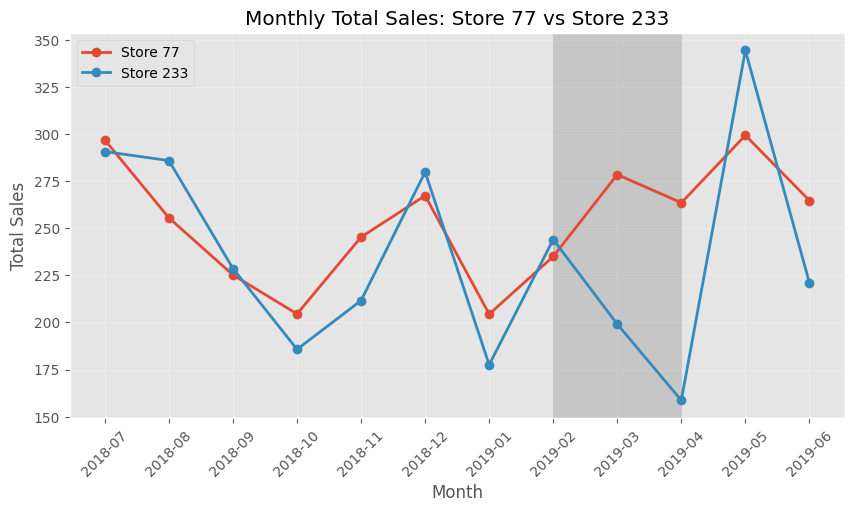

In [ ]:
import matplotlib.pyplot as plt

trial_store = 77
control_store = 233

plt.figure(figsize=(10,5))

for store in [trial_store, control_store]:
    temp = comparison[comparison["STORE_NBR"] == store]

    plt.plot(
        temp["YEARMONTH"].astype(str),
        temp["TOT_SALES"],
        marker="o",
        linewidth=2,
        label=f"Store {store}"
    )

# Highlight the trial period
plt.axvspan("2019-02", "2019-04", color="gray", alpha=0.3)

plt.title("Monthly Total Sales: Store 77 vs Store 233")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.legend()
plt.grid(alpha=0.3)

plt.show()

**Plot Number of Customers**

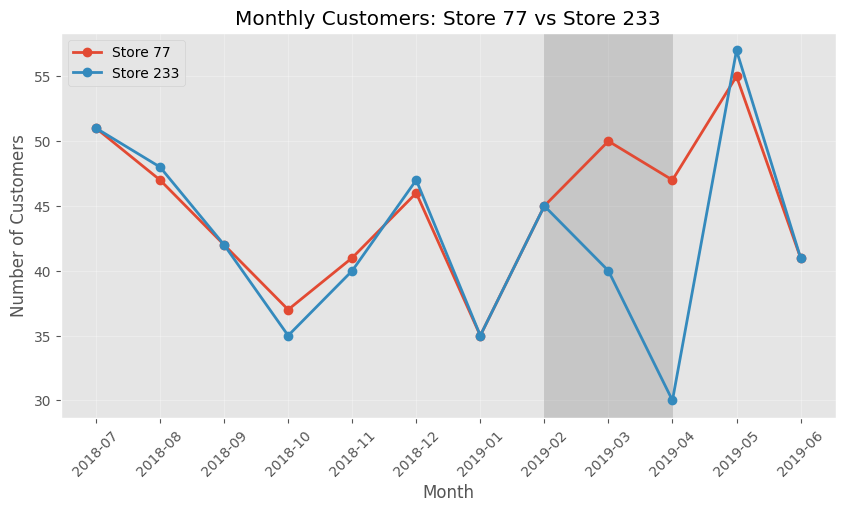

In [ ]:
plt.figure(figsize=(10,5))

for store in [trial_store, control_store]:
    temp = comparison[comparison["STORE_NBR"] == store]

    plt.plot(
        temp["YEARMONTH"].astype(str),
        temp["N_CUSTOMERS"],
        marker="o",
        linewidth=2,
        label=f"Store {store}"
    )

plt.axvspan("2019-02", "2019-04", color="gray", alpha=0.3)

plt.title("Monthly Customers: Store 77 vs Store 233")
plt.xlabel("Month")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.legend()
plt.grid(alpha=0.3)

plt.show()

**Plot Transactions per Customer**

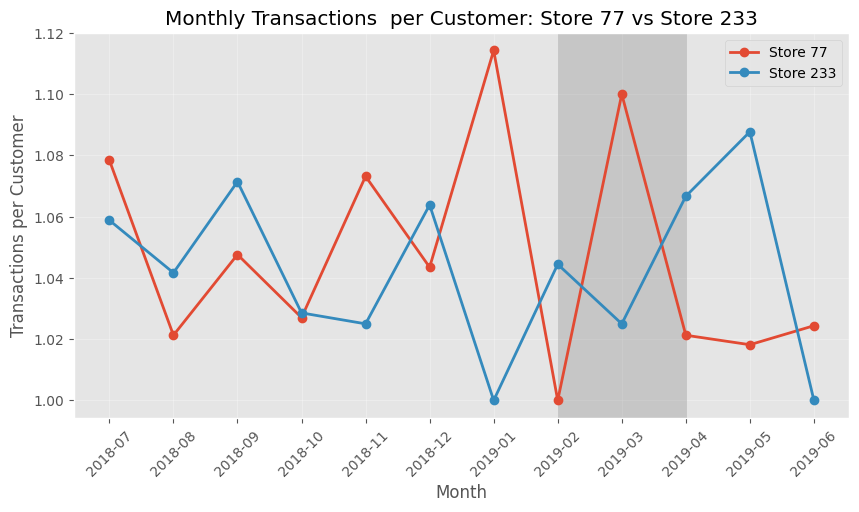

In [ ]:
plt.figure(figsize=(10,5))

for store in [trial_store, control_store]:
    temp = comparison[comparison["STORE_NBR"] == store]

    plt.plot(
        temp["YEARMONTH"].astype(str),
        temp["TXN_PER_CUSTOMER"],
        marker="o",
        linewidth=2,
        label=f"Store {store}"
    )

plt.axvspan("2019-02", "2019-04", color="gray", alpha=0.3)

plt.title("Monthly Transactions  per Customer: Store 77 vs Store 233")
plt.xlabel("Month")
plt.ylabel("Transactions per Customer")
plt.xticks(rotation=45)
plt.legend()
plt.grid(alpha=0.3)

plt.show()

Spliting the data

In [ ]:
# Pre-trial period
pre_trial = comparison[comparison["YEARMONTH"] < "2019-02"]

# Trial period
trial = comparison[
    (comparison["YEARMONTH"] >= "2019-02") &
    (comparison["YEARMONTH"] <= "2019-06")
]

Calculating average metrics

In [ ]:
pre_summary = (
    pre_trial.groupby("STORE_NBR")
    .agg(
        AVG_SALES=("TOT_SALES", "mean"),
        AVG_CUSTOMERS=("N_CUSTOMERS", "mean"),
        AVG_TXN_PER_CUSTOMER=("TXN_PER_CUSTOMER", "mean")
    )
)

trial_summary = (
    trial.groupby("STORE_NBR")
    .agg(
        AVG_SALES=("TOT_SALES", "mean"),
        AVG_CUSTOMERS=("N_CUSTOMERS", "mean"),
        AVG_TXN_PER_CUSTOMER=("TXN_PER_CUSTOMER", "mean")
    )
)

print("Pre-Trial")
print(pre_summary)

print("\nTrial")
print(trial_summary)

Pre-Trial
            AVG_SALES  AVG_CUSTOMERS  AVG_TXN_PER_CUSTOMER
STORE_NBR                                                 
77         242.714286      42.714286              1.057898
233        237.114286      42.571429              1.041331

Trial
           AVG_SALES  AVG_CUSTOMERS  AVG_TXN_PER_CUSTOMER
STORE_NBR                                                
77            268.20           47.6              1.032770
233           233.42           42.6              1.044766


Calculating percentage change

In [ ]:
comparison_summary = pre_summary.copy()

comparison_summary["TRIAL_AVG_SALES"] = trial_summary["AVG_SALES"]
comparison_summary["TRIAL_AVG_CUSTOMERS"] = trial_summary["AVG_CUSTOMERS"]
comparison_summary["TRIAL_AVG_TXN"] = trial_summary["AVG_TXN_PER_CUSTOMER"]

comparison_summary["SALES_%_CHANGE"] = (
    (comparison_summary["TRIAL_AVG_SALES"] -
     comparison_summary["AVG_SALES"])
    / comparison_summary["AVG_SALES"] * 100
)

comparison_summary["CUSTOMERS_%_CHANGE"] = (
    (comparison_summary["TRIAL_AVG_CUSTOMERS"] -
     comparison_summary["AVG_CUSTOMERS"])
    / comparison_summary["AVG_CUSTOMERS"] * 100
)

comparison_summary["TXN_%_CHANGE"] = (
    (comparison_summary["TRIAL_AVG_TXN"] -
     comparison_summary["AVG_TXN_PER_CUSTOMER"])
    / comparison_summary["AVG_TXN_PER_CUSTOMER"] * 100
)

comparison_summary.round(2)

,AVG_SALES,AVG_CUSTOMERS,AVG_TXN_PER_CUSTOMER,TRIAL_AVG_SALES,TRIAL_AVG_CUSTOMERS,TRIAL_AVG_TXN,SALES_%_CHANGE,CUSTOMERS_%_CHANGE,TXN_%_CHANGE
STORE_NBR,,,,,,,,,
77,242.71,42.71,1.06,268.20,47.6,1.03,10.50,11.44,-2.38
233,237.11,42.57,1.04,233.42,42.6,1.04,-1.56,0.07,0.33


Calculating the scaling factor

In [ ]:
monthly_metrics[monthly_metrics["STORE_NBR"] == 233]

,STORE_NBR,YEARMONTH,TOT_SALES,N_CUSTOMERS,N_TRANSACTIONS,TXN_PER_CUSTOMER
2699,233,2018-07,290.7,51,54,1.058824
2700,233,2018-08,285.9,48,50,1.041667
2701,233,2018-09,228.6,42,45,1.071429
2702,233,2018-10,185.7,35,36,1.028571
2703,233,2018-11,211.6,40,41,1.025000
2704,233,2018-12,279.8,47,50,1.063830
2705,233,2019-01,177.5,35,35,1.000000
2706,233,2019-02,244.0,45,47,1.044444
2707,233,2019-03,199.1,40,41,1.025000
2708,233,2019-04,158.6,30,32,1.066667


In [ ]:
monthly_metrics["TXN_PER_CUSTOMER"] = (
    monthly_metrics["N_TRANSACTIONS"] /
    monthly_metrics["N_CUSTOMERS"]
)

monthly_metrics.head()

,STORE_NBR,YEARMONTH,TOT_SALES,N_CUSTOMERS,N_TRANSACTIONS,TXN_PER_CUSTOMER
0,1,2018-07,206.9,49,52,1.061224
1,1,2018-08,176.1,42,43,1.023810
2,1,2018-09,278.8,59,62,1.050847
3,1,2018-10,188.1,44,45,1.022727
4,1,2018-11,192.6,46,47,1.021739


In [ ]:
print(monthly_metrics.shape)
print(monthly_metrics.columns)

(3169, 6)
Index(['STORE_NBR', 'YEARMONTH', 'TOT_SALES', 'N_CUSTOMERS', 'N_TRANSACTIONS',
       'TXN_PER_CUSTOMER'],
      dtype='object')


Calculating the scaling factor

In [ ]:
trial_store = monthly_metrics[
    monthly_metrics["STORE_NBR"] == 77
].copy()

control_store = monthly_metrics[
    monthly_metrics["STORE_NBR"] == 233
].copy()

print(trial_store.shape)
print(control_store.shape)

(12, 6)
(12, 6)


In [ ]:
# Pre-trial data
trial_pre = trial_store[trial_store["YEARMONTH"] < "2019-02"]
control_pre = control_store[control_store["YEARMONTH"] < "2019-02"]

# Scaling factor
scaling_factor = (
    trial_pre["TOT_SALES"].sum() /
    control_pre["TOT_SALES"].sum()
)

print(f"Scaling Factor: {scaling_factor:.4f}")

Scaling Factor: 1.0236


Scale the control store

In [ ]:
control_store["SCALED_SALES"] = (
    control_store["TOT_SALES"] * scaling_factor
)

control_store

,STORE_NBR,YEARMONTH,TOT_SALES,N_CUSTOMERS,N_TRANSACTIONS,TXN_PER_CUSTOMER,SCALED_SALES
2699,233,2018-07,290.7,51,54,1.058824,297.565550
2700,233,2018-08,285.9,48,50,1.041667,292.652187
2701,233,2018-09,228.6,42,45,1.071429,233.998916
2702,233,2018-10,185.7,35,36,1.028571,190.085733
2703,233,2018-11,211.6,40,41,1.025000,216.597421
2704,233,2018-12,279.8,47,50,1.063830,286.408121
2705,233,2019-01,177.5,35,35,1.000000,181.692071
2706,233,2019-02,244.0,45,47,1.044444,249.762622
2707,233,2019-03,199.1,40,41,1.025000,203.802205
2708,233,2019-04,158.6,30,32,1.066667,162.345704


Merging the two stores

In [ ]:
sales_compare = trial_store[
    ["YEARMONTH", "TOT_SALES"]
].merge(
    control_store[
        ["YEARMONTH", "SCALED_SALES"]
    ],
    on="YEARMONTH"
)

sales_compare

,YEARMONTH,TOT_SALES,SCALED_SALES
0,2018-07,296.8,297.565550
1,2018-08,255.5,292.652187
2,2018-09,225.2,233.998916
3,2018-10,204.5,190.085733
4,2018-11,245.3,216.597421
5,2018-12,267.3,286.408121
6,2019-01,204.4,181.692071
7,2019-02,235.0,249.762622
8,2019-03,278.5,203.802205
9,2019-04,263.5,162.345704


Calculate the percentage difference during the pre-trial period

In [ ]:
pre_sales = sales_compare[
    sales_compare["YEARMONTH"] < "2019-02"
].copy()

pre_sales["PERCENT_DIFF"] = (
    (pre_sales["TOT_SALES"] - pre_sales["SCALED_SALES"])
    / pre_sales["SCALED_SALES"]
)

pre_sales

,YEARMONTH,TOT_SALES,SCALED_SALES,PERCENT_DIFF
0,2018-07,296.8,297.565550,-0.002573
1,2018-08,255.5,292.652187,-0.126950
2,2018-09,225.2,233.998916,-0.037602
3,2018-10,204.5,190.085733,0.075830
4,2018-11,245.3,216.597421,0.132516
5,2018-12,267.3,286.408121,-0.066716
6,2019-01,204.4,181.692071,0.124980


Calculate the standard deviation

In [ ]:
std_dev = pre_sales["PERCENT_DIFF"].std()

print(f"Standard Deviation: {std_dev:.4f}")

Standard Deviation: 0.0996


In [ ]:
n = len(pre_sales)
print("Number of pre-trial months:", n)

Number of pre-trial months: 7


Calculate the t-values for all months

In [ ]:
sales_compare["PERCENT_DIFF"] = (
    (sales_compare["TOT_SALES"] - sales_compare["SCALED_SALES"])
    / sales_compare["SCALED_SALES"]
)

sales_compare["T_VALUE"] = (
    sales_compare["PERCENT_DIFF"] / std_dev
)

sales_compare

,YEARMONTH,TOT_SALES,SCALED_SALES,PERCENT_DIFF,T_VALUE
0,2018-07,296.8,297.565550,-0.002573,-0.025834
1,2018-08,255.5,292.652187,-0.126950,-1.274771
2,2018-09,225.2,233.998916,-0.037602,-0.377585
3,2018-10,204.5,190.085733,0.075830,0.761452
4,2018-11,245.3,216.597421,0.132516,1.330661
5,2018-12,267.3,286.408121,-0.066716,-0.669934
6,2019-01,204.4,181.692071,0.124980,1.254993
7,2019-02,235.0,249.762622,-0.059107,-0.593520
8,2019-03,278.5,203.802205,0.366521,3.680430
9,2019-04,263.5,162.345704,0.623080,6.256669


Check the trial months

In [ ]:
trial_results = sales_compare[
    (sales_compare["YEARMONTH"] >= "2019-02") &
    (sales_compare["YEARMONTH"] <= "2019-04")
]

trial_results[["YEARMONTH", "TOT_SALES", "SCALED_SALES", "T_VALUE"]]

,YEARMONTH,TOT_SALES,SCALED_SALES,T_VALUE
7,2019-02,235.0,249.762622,-0.593520
8,2019-03,278.5,203.802205,3.680430
9,2019-04,263.5,162.345704,6.256669


**confidence interval visualization**

In [ ]:
# Calculate upper and lower confidence limits
sales_compare["UPPER_CI"] = (
    sales_compare["SCALED_SALES"] * (1 + 2.447 * std_dev)
)

sales_compare["LOWER_CI"] = (
    sales_compare["SCALED_SALES"] * (1 - 2.447 * std_dev)
)

sales_compare

,YEARMONTH,TOT_SALES,SCALED_SALES,PERCENT_DIFF,T_VALUE,UPPER_CI,LOWER_CI
0,2018-07,296.8,297.565550,-0.002573,-0.025834,370.078730,225.052370
1,2018-08,255.5,292.652187,-0.126950,-1.274771,363.968039,221.336335
2,2018-09,225.2,233.998916,-0.037602,-0.377585,291.021664,176.976167
3,2018-10,204.5,190.085733,0.075830,0.761452,236.407362,143.764104
4,2018-11,245.3,216.597421,0.132516,1.330661,269.379633,163.815210
5,2018-12,267.3,286.408121,-0.066716,-0.669934,356.202369,216.613874
6,2019-01,204.4,181.692071,0.124980,1.254993,225.968265,137.415878
7,2019-02,235.0,249.762622,-0.059107,-0.593520,310.626798,188.898446
8,2019-03,278.5,203.802205,0.366521,3.680430,253.466375,154.138035
9,2019-04,263.5,162.345704,0.623080,6.256669,201.907419,122.783990


In [ ]:
print(sales_compare.dtypes)

YEARMONTH       period[M]
TOT_SALES         float64
SCALED_SALES      float64
PERCENT_DIFF      float64
T_VALUE           float64
UPPER_CI          float64
LOWER_CI          float64
dtype: object


In [ ]:
sales_compare["YEARMONTH"] = sales_compare["YEARMONTH"].astype(str)

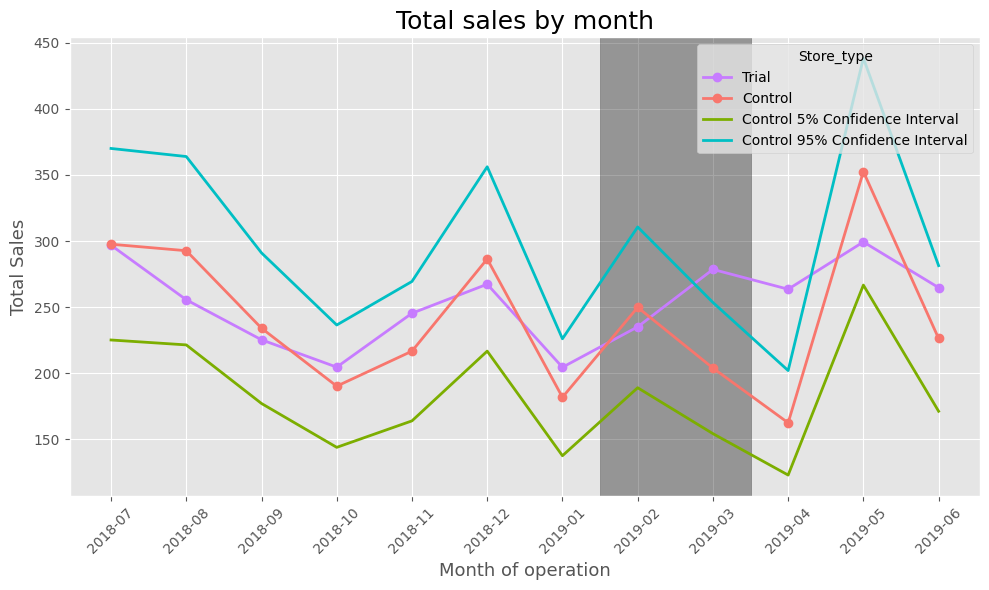

In [ ]:
import matplotlib.pyplot as plt

# Convert Period to string for plotting
sales_compare["YEARMONTH"] = sales_compare["YEARMONTH"].astype(str)

plt.style.use("ggplot")
plt.figure(figsize=(10,6))

# Trial
plt.plot(
    sales_compare["YEARMONTH"],
    sales_compare["TOT_SALES"],
    color="#C77CFF",          # Purple (like R)
    marker="o",
    linewidth=2,
    label="Trial"
)

# Control
plt.plot(
    sales_compare["YEARMONTH"],
    sales_compare["SCALED_SALES"],
    color="#F8766D",          # Red (ggplot2 default)
    marker="o",
    linewidth=2,
    label="Control"
)

# Lower CI (5%)
plt.plot(
    sales_compare["YEARMONTH"],
    sales_compare["LOWER_CI"],
    color="#7CAE00",          # Green (ggplot2 default)
    linewidth=2,
    label="Control 5% Confidence Interval"
)

# Upper CI (95%)
plt.plot(
    sales_compare["YEARMONTH"],
    sales_compare["UPPER_CI"],
    color="#00BFC4",          # Cyan (ggplot2 default)
    linewidth=2,
    label="Control 95% Confidence Interval"
)

# Trial period (Feb-Apr 2019)
plt.axvspan(6.5, 8.5, color="black", alpha=0.35)

plt.title("Total sales by month", fontsize=18)
plt.xlabel("Month of operation", fontsize=13)
plt.ylabel("Total Sales", fontsize=13)

plt.xticks(rotation=45)

# Legend INSIDE the plot (top-right)
plt.legend(
    title="Store_type",
    loc="upper right",
    frameon=True
)

plt.tight_layout()
plt.show()

## Find the control store for Store 86

In [ ]:
pre_trial = monthly_metrics[
    monthly_metrics["YEARMONTH"] < "2019-02"
]

similarity for total sales.

In [ ]:
trial_store = 86

trial_sales = pre_trial[
    pre_trial["STORE_NBR"] == trial_store
][["YEARMONTH", "TOT_SALES"]]

sales_scores = []

for store in pre_trial["STORE_NBR"].unique():

    if store == trial_store:
        continue

    control_sales = pre_trial[
        pre_trial["STORE_NBR"] == store
    ][["YEARMONTH", "TOT_SALES"]]

    merged = trial_sales.merge(
        control_sales,
        on="YEARMONTH",
        suffixes=("_trial", "_control")
    )

    if len(merged) == 7:

        corr = merged["TOT_SALES_trial"].corr(
            merged["TOT_SALES_control"]
        )

        distance = abs(
            merged["TOT_SALES_trial"] -
            merged["TOT_SALES_control"]
        ).sum()

        sales_scores.append(
            [store, corr, distance]
        )

sales_scores = pd.DataFrame(
    sales_scores,
    columns=["STORE_NBR", "CORRELATION", "DISTANCE"]
)

Normalize the distance:

In [ ]:
sales_scores["MAGNITUDE"] = 1 - (
    (sales_scores["DISTANCE"] - sales_scores["DISTANCE"].min())
    /
    (sales_scores["DISTANCE"].max() - sales_scores["DISTANCE"].min())
)

sales_scores["FINAL_SCORE"] = (
    sales_scores["CORRELATION"] +
    sales_scores["MAGNITUDE"]
) / 2

sales_scores.sort_values(
    "FINAL_SCORE",
    ascending=False
).head(10)

,STORE_NBR,CORRELATION,DISTANCE,MAGNITUDE,FINAL_SCORE
146,155,0.877882,227.25,0.998964,0.938423
209,222,0.795075,251.05,0.994853,0.894964
101,109,0.788300,221.25,1.000000,0.894150
129,138,0.759864,458.05,0.959103,0.859483
106,114,0.734415,481.30,0.955087,0.844751
255,269,0.697055,601.85,0.934267,0.815661
98,106,0.678684,547.80,0.943602,0.811143
212,225,0.617533,262.75,0.992833,0.805183
119,128,0.654929,825.05,0.895719,0.775324
74,79,0.668748,1023.30,0.861479,0.765113


Best control store for Trial Store 86: Store 155

### Create the trial and control datasets

In [ ]:
# Store 86 (Trial) and Store 155 (Control)

trial_store = monthly_metrics[
    monthly_metrics["STORE_NBR"] == 86
].copy()

control_store = monthly_metrics[
    monthly_metrics["STORE_NBR"] == 155
].copy()

print(trial_store.shape)
print(control_store.shape)

(12, 6)
(12, 6)


Calculate the scaling factor

In [ ]:
# Pre-trial period (Jul 2018 - Jan 2019)

trial_pre = trial_store[
    trial_store["YEARMONTH"] < "2019-02"
]

control_pre = control_store[
    control_store["YEARMONTH"] < "2019-02"
]

scaling_factor = (
    trial_pre["TOT_SALES"].sum() /
    control_pre["TOT_SALES"].sum()
)

print(f"Scaling Factor: {scaling_factor:.4f}")

Scaling Factor: 0.9701


Scale the control store

In [ ]:
control_store["SCALED_SALES"] = (
    control_store["TOT_SALES"] * scaling_factor
)

Merge the two stores

In [ ]:
#Merge the two stores
sales_compare = trial_store[
    ["YEARMONTH", "TOT_SALES"]
].merge(
    control_store[
        ["YEARMONTH", "SCALED_SALES"]
    ],
    on="YEARMONTH"
)

sales_compare

,YEARMONTH,TOT_SALES,SCALED_SALES
0,2018-07,892.20,896.922236
1,2018-08,764.05,759.269991
2,2018-09,914.60,984.034086
3,2018-10,948.40,934.948790
4,2018-11,918.00,871.894555
5,2018-12,841.20,824.361363
6,2019-01,841.40,848.418979
7,2019-02,913.20,864.522060
8,2019-03,1026.80,780.320405
9,2019-04,848.20,819.317024


Calculate percentage differences

In [ ]:
#Calculate percentage differences
pre_sales = sales_compare[
    sales_compare["YEARMONTH"] < "2019-02"
].copy()

pre_sales["PERCENT_DIFF"] = (
    (pre_sales["TOT_SALES"] - pre_sales["SCALED_SALES"])
    / pre_sales["SCALED_SALES"]
)

std_dev = pre_sales["PERCENT_DIFF"].std()

print("Standard Deviation:", round(std_dev,4))

Standard Deviation: 0.0377


Calculate t-values

In [ ]:
#Calculate t-values
sales_compare["PERCENT_DIFF"] = (
    (sales_compare["TOT_SALES"] - sales_compare["SCALED_SALES"])
    / sales_compare["SCALED_SALES"]
)

sales_compare["T_VALUE"] = (
    sales_compare["PERCENT_DIFF"] / std_dev
)

trial_results = sales_compare[
    (sales_compare["YEARMONTH"] >= "2019-02") &
    (sales_compare["YEARMONTH"] <= "2019-04")
]

trial_results

,YEARMONTH,TOT_SALES,SCALED_SALES,PERCENT_DIFF,T_VALUE
7,2019-02,913.2,864.522060,0.056306,1.494114
8,2019-03,1026.8,780.320405,0.315870,8.381769
9,2019-04,848.2,819.317024,0.035253,0.935444


**Interpretation**

* **February**: Sales increased, but **not enough** to be statistically significant.
* **March**: Very large, statistically significant increase in sales.
* **April**: Sales remained slightly above expected, but the increase was not statistically significant.

Business conclusion: The trial at Store 86 appears to have had a positive impact in March, but the effect was not sustained across the full trial period.

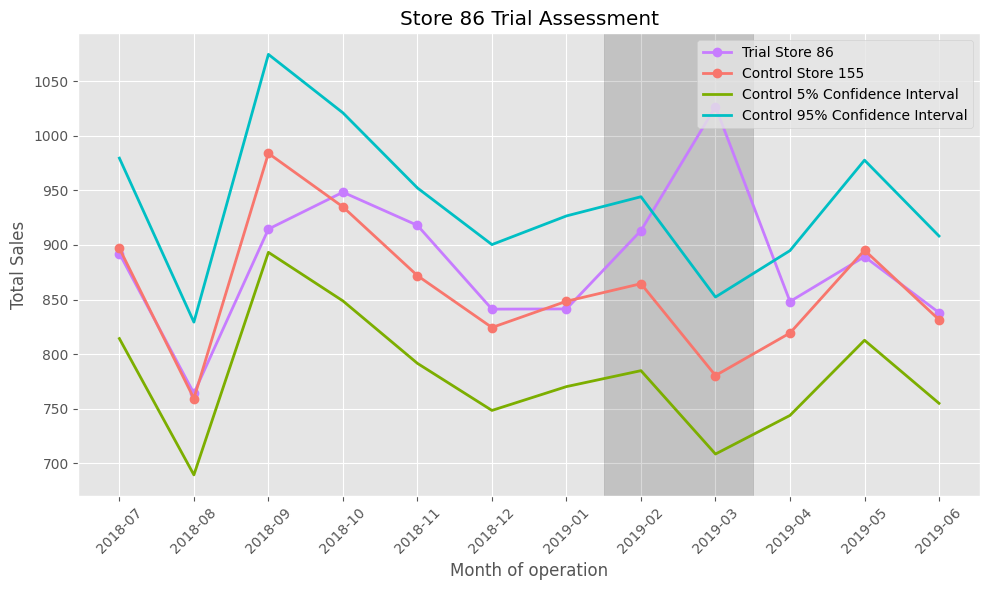

In [ ]:
import matplotlib.pyplot as plt

# Convert Period to string (only if needed)
sales_compare["YEARMONTH"] = sales_compare["YEARMONTH"].astype(str)

# Confidence interval
sales_compare["UPPER_CI"] = sales_compare["SCALED_SALES"] * (1 + 2.447 * std_dev)
sales_compare["LOWER_CI"] = sales_compare["SCALED_SALES"] * (1 - 2.447 * std_dev)

plt.style.use("ggplot")
plt.figure(figsize=(10,6))

# Trial Store
plt.plot(
    sales_compare["YEARMONTH"],
    sales_compare["TOT_SALES"],
    marker="o",
    linewidth=2,
    color="#C77CFF",
    label="Trial Store 86"
)

# Control Store
plt.plot(
    sales_compare["YEARMONTH"],
    sales_compare["SCALED_SALES"],
    marker="o",
    linewidth=2,
    color="#F8766D",
    label="Control Store 155"
)

# Lower CI
plt.plot(
    sales_compare["YEARMONTH"],
    sales_compare["LOWER_CI"],
    linewidth=2,
    color="#7CAE00",
    label="Control 5% Confidence Interval"
)

# Upper CI
plt.plot(
    sales_compare["YEARMONTH"],
    sales_compare["UPPER_CI"],
    linewidth=2,
    color="#00BFC4",
    label="Control 95% Confidence Interval"
)

# Highlight trial period
plt.axvspan(6.5, 8.5, color="black", alpha=0.15)

plt.title("Store 86 Trial Assessment")
plt.xlabel("Month of operation")
plt.ylabel("Total Sales")

plt.legend(loc="upper right")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### For Store 88

In [ ]:
trial_store = 88

trial_sales = pre_trial[
    pre_trial["STORE_NBR"] == trial_store
][["YEARMONTH", "TOT_SALES"]]

sales_scores = []

for store in pre_trial["STORE_NBR"].unique():

    if store == trial_store:
        continue

    control_sales = pre_trial[
        pre_trial["STORE_NBR"] == store
    ][["YEARMONTH", "TOT_SALES"]]

    merged = trial_sales.merge(
        control_sales,
        on="YEARMONTH",
        suffixes=("_trial", "_control")
    )

    if len(merged) == 7:

        corr = merged["TOT_SALES_trial"].corr(
            merged["TOT_SALES_control"]
        )

        distance = abs(
            merged["TOT_SALES_trial"] -
            merged["TOT_SALES_control"]
        ).sum()

        sales_scores.append(
            [store, corr, distance]
        )

sales_scores = pd.DataFrame(
    sales_scores,
    columns=["STORE_NBR", "CORRELATION", "DISTANCE"]
)

In [ ]:
sales_scores["MAGNITUDE"] = 1 - (
    (sales_scores["DISTANCE"] - sales_scores["DISTANCE"].min())
    /
    (sales_scores["DISTANCE"].max() - sales_scores["DISTANCE"].min())
)

sales_scores["FINAL_SCORE"] = (
    sales_scores["CORRELATION"] +
    sales_scores["MAGNITUDE"]
) / 2

sales_scores.sort_values(
    "FINAL_SCORE",
    ascending=False
).head(10)

,STORE_NBR,CORRELATION,DISTANCE,MAGNITUDE,FINAL_SCORE
116,125,0.624109,1375.85,0.890950,0.757529
193,203,0.508001,462.70,0.993943,0.750972
84,91,0.776688,3153.60,0.690439,0.733564
6,7,0.649657,2070.10,0.812646,0.731151
169,178,0.731857,2839.10,0.725911,0.728884
191,201,0.492735,1188.20,0.912115,0.702425
98,106,0.644724,2797.15,0.730643,0.687683
74,79,0.576960,2240.45,0.793432,0.685196
224,237,0.308479,409.00,1.000000,0.654240
146,155,0.600771,3074.90,0.699315,0.650043


Best control store for Trial Store 88: Store 125

### Create the trial and control datasets

In [ ]:
# Store 86 (Trial) and Store 155 (Control)

trial_store = monthly_metrics[
    monthly_metrics["STORE_NBR"] == 88
].copy()

control_store = monthly_metrics[
    monthly_metrics["STORE_NBR"] == 125
].copy()

print(trial_store.shape)
print(control_store.shape)

(12, 6)
(12, 6)


Calculate the scaling factor

In [ ]:
# Pre-trial period (Jul 2018 - Jan 2019)

trial_pre = trial_store[
    trial_store["YEARMONTH"] < "2019-02"
]

control_pre = control_store[
    control_store["YEARMONTH"] < "2019-02"
]

scaling_factor = (
    trial_pre["TOT_SALES"].sum() /
    control_pre["TOT_SALES"].sum()
)

print(f"Scaling Factor: {scaling_factor:.4f}")

Scaling Factor: 1.1718


Scale the control store

In [ ]:
control_store["SCALED_SALES"] = (
    control_store["TOT_SALES"] * scaling_factor
)

Merge the two stores

In [ ]:
sales_compare = trial_store[
    ["YEARMONTH", "TOT_SALES"]
].merge(
    control_store[
        ["YEARMONTH", "SCALED_SALES"]
    ],
    on="YEARMONTH"
)

sales_compare

,YEARMONTH,TOT_SALES,SCALED_SALES
0,2018-07,1310.00,1218.453034
1,2018-08,1323.80,1306.280553
2,2018-09,1423.00,1426.332980
3,2018-10,1352.40,1313.252851
4,2018-11,1382.80,1390.944173
5,2018-12,1325.20,1427.973521
6,2019-01,1266.40,1300.362888
7,2019-02,1370.20,1073.147998
8,2019-03,1477.20,1447.660009
9,2019-04,1439.40,1298.605166


Calculate percentage differences

In [ ]:
pre_sales = sales_compare[
    sales_compare["YEARMONTH"] < "2019-02"
].copy()

pre_sales["PERCENT_DIFF"] = (
    (pre_sales["TOT_SALES"] - pre_sales["SCALED_SALES"])
    / pre_sales["SCALED_SALES"]
)

std_dev = pre_sales["PERCENT_DIFF"].std()

print("Standard Deviation:", round(std_dev,4))

Standard Deviation: 0.0458


Calculate t-values

In [ ]:
sales_compare["PERCENT_DIFF"] = (
    (sales_compare["TOT_SALES"] - sales_compare["SCALED_SALES"])
    / sales_compare["SCALED_SALES"]
)

sales_compare["T_VALUE"] = (
    sales_compare["PERCENT_DIFF"] / std_dev
)

trial_results = sales_compare[
    (sales_compare["YEARMONTH"] >= "2019-02") &
    (sales_compare["YEARMONTH"] <= "2019-04")
]

trial_results

,YEARMONTH,TOT_SALES,SCALED_SALES,PERCENT_DIFF,T_VALUE
7,2019-02,1370.2,1073.147998,0.276804,6.041677
8,2019-03,1477.2,1447.660009,0.020405,0.445378
9,2019-04,1439.4,1298.605166,0.108420,2.366433


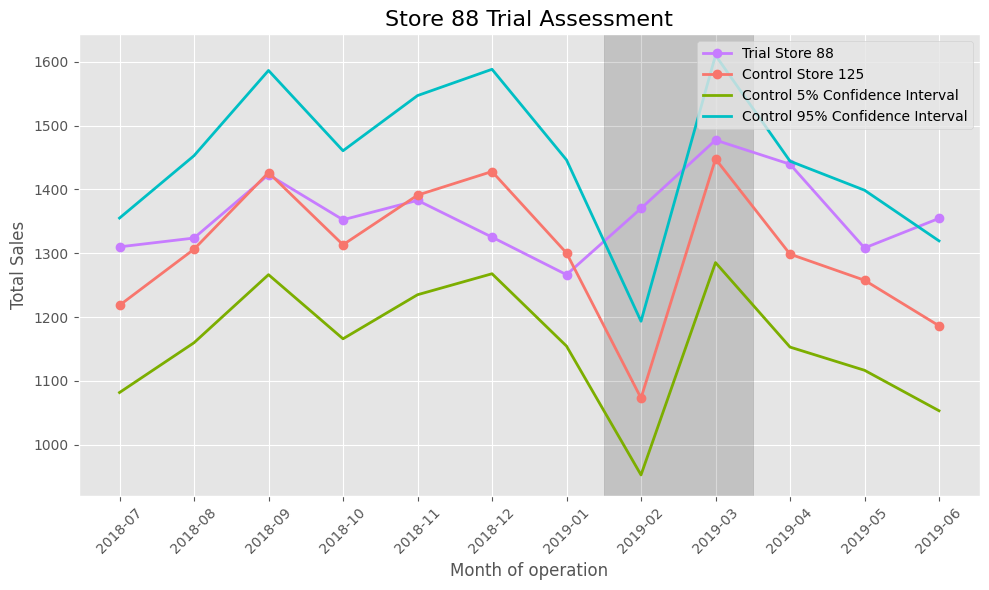

In [ ]:
import matplotlib.pyplot as plt

# Convert to string if needed
sales_compare["YEARMONTH"] = sales_compare["YEARMONTH"].astype(str)

# Confidence intervals
sales_compare["UPPER_CI"] = sales_compare["SCALED_SALES"] * (1 + 2.447 * std_dev)
sales_compare["LOWER_CI"] = sales_compare["SCALED_SALES"] * (1 - 2.447 * std_dev)

plt.style.use("ggplot")
plt.figure(figsize=(10,6))

# Trial Store 88
plt.plot(
    sales_compare["YEARMONTH"],
    sales_compare["TOT_SALES"],
    marker="o",
    linewidth=2,
    color="#C77CFF",
    label="Trial Store 88"
)

# Control Store 125
plt.plot(
    sales_compare["YEARMONTH"],
    sales_compare["SCALED_SALES"],
    marker="o",
    linewidth=2,
    color="#F8766D",
    label="Control Store 125"
)

# 5% Confidence Interval
plt.plot(
    sales_compare["YEARMONTH"],
    sales_compare["LOWER_CI"],
    linewidth=2,
    color="#7CAE00",
    label="Control 5% Confidence Interval"
)

# 95% Confidence Interval
plt.plot(
    sales_compare["YEARMONTH"],
    sales_compare["UPPER_CI"],
    linewidth=2,
    color="#00BFC4",
    label="Control 95% Confidence Interval"
)

# Highlight trial period (Feb–Apr 2019)
plt.axvspan(6.5, 8.5, color="black", alpha=0.15)

plt.title("Store 88 Trial Assessment", fontsize=16)
plt.xlabel("Month of operation", fontsize=12)
plt.ylabel("Total Sales", fontsize=12)

plt.xticks(rotation=45)
plt.legend(loc="upper right")

plt.tight_layout()
plt.show()

**Final recommendation for Julia**

You can write something like this in your report:



> **Store 77** demonstrated a clear and sustained positive impact from the new store layout, with statistically significant increases in sales during March and April 2019. This suggests the trial was successful at this location.

> **Store 86** showed a statistically significant increase in sales during March 2019 only. Although there was evidence of improvement, the effect was not consistent across the entire trial period.

> **Store 88** experienced a statistically significant increase in February 2019; however, the effect was not maintained during March and April, indicating only a temporary improvement.

> Overall, Store 77 provides the strongest evidence that the new layout positively influenced sales, while Stores 86 and 88 produced mixed results. It is recommended that the client investigate local factors influencing the inconsistent performance before rolling out the layout to all stores.




